# 1. Imports et fonctions d'évaluation

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))

sns.set_theme(style="whitegrid")



def cmapss_penalty(d: float) -> float:
  """Calcule la pénalité NASA individuelle pour un écart d = pred - true."""
  return np.exp(-d / 13.0) - 1.0 if d < 0 else np.exp(d / 10.0) - 1.0

# 2. Reconstituer la table des erreurs sur les 248 moteurs de test

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd


# Fonction de pénalité asymétrique officielle NASA
def cmapss_penalty(d: float) -> float:
  """Pénalité individuelle : retard (d >= 0) sur-pénalisé par rapport à l'avance (d < 0)."""
  return np.exp(-d / 13.0) - 1.0 if d < 0 else np.exp(d / 10.0) - 1.0


DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")

# 1. Cibles réelles
rul_true = pd.read_csv(
    DATA_RAW / "RUL_FD004.txt", sep=r"\s+", header=None, names=["rul_true"]
)
rul_true["rul_clipped"] = rul_true["rul_true"].clip(upper=125)
y_test = rul_true["rul_true"].clip(upper=125).values

# 2. Dernière durée observée de chaque moteur en test
df_test = pd.read_parquet(DATA_PROCESSED / "test_FD004_features.parquet")
last_cycles = (
    df_test.groupby("unit_id")["time_cycles"]
    .max()
    .reset_index(name="last_cycle")
)
y_pred_lgb = np.load(DATA_PROCESSED / "y_pred_lgb.npy")
# 3. Assemblage du tableau d'analyse
df_errors = pd.DataFrame({
    "unit_id": np.arange(1, len(y_test) + 1),
    "rul_true": y_test,
    "rul_pred": y_pred_lgb,
    "last_cycle": last_cycles["last_cycle"].values,
})

# Calcul des métriques individuelles
df_errors["error"] = (
    df_errors["rul_pred"] - df_errors["rul_true"]
)  # >0 = retard, <0 = avance
df_errors["abs_error"] = df_errors["error"].abs()
df_errors["nasa_penalty"] = df_errors["error"].apply(cmapss_penalty)
df_errors["type_erreur"] = np.where(
    df_errors["error"] >= 0, "Tardive (Dangereuse)", "Précoce (Conservatrice)"
)

print(f"Moteurs analysés : {len(df_errors)}")
display(df_errors.head())

Moteurs analysés : 248


,unit_id,rul_true,rul_pred,last_cycle,error,abs_error,nasa_penalty,type_erreur
0,1,22,38.512001,230,16.512001,16.512001,4.213233,Tardive (Dangereuse)
1,2,39,81.536215,153,42.536215,42.536215,69.359759,Tardive (Dangereuse)
2,3,107,91.055283,141,-15.944717,15.944717,2.409333,Précoce (Conservatrice)
3,4,75,112.906416,208,37.906416,37.906416,43.284806,Tardive (Dangereuse)
4,5,125,91.065091,51,-33.934909,33.934909,12.604187,Précoce (Conservatrice)


# 3. Identifier le « Top 10 » des moteurs responsables de l'explosion du score NASA

In [4]:
worst_nasa = df_errors.sort_values(by="nasa_penalty", ascending=False).head(10)

print(
    f"Score NASA total sur les 248 moteurs : {df_errors['nasa_penalty'].sum():.1f}"
)
print(
    f"Part des 10 pires moteurs : {worst_nasa['nasa_penalty'].sum() / df_errors['nasa_penalty'].sum() * 100:.1f} % du total !\n"
)

display(
    worst_nasa[[
        "unit_id",
        "rul_true",
        "rul_pred",
        "error",
        "nasa_penalty",
        "type_erreur",
    ]]
)

Score NASA total sur les 248 moteurs : 3148.0
Part des 10 pires moteurs : 66.2 % du total !



,unit_id,rul_true,rul_pred,error,nasa_penalty,type_erreur
42,43,42,108.254879,66.254879,753.072014,Tardive (Dangereuse)
76,77,25,86.640276,61.640276,474.338686,Tardive (Dangereuse)
106,107,41,93.699937,52.699937,193.414737,Tardive (Dangereuse)
188,189,56,106.088930,50.088930,148.738877,Tardive (Dangereuse)
170,171,125,62.244296,-62.755704,123.881068,Précoce (Conservatrice)
239,240,98,38.837965,-59.162035,93.720059,Précoce (Conservatrice)
87,88,56,101.237569,45.237569,91.181267,Tardive (Dangereuse)
165,166,72,115.717936,43.717936,78.185530,Tardive (Dangereuse)
1,2,39,81.536215,42.536215,69.359759,Tardive (Dangereuse)
200,201,59,99.583764,40.583764,56.880258,Tardive (Dangereuse)


# 4. Distribution des résidus et asymétrie des pénalités

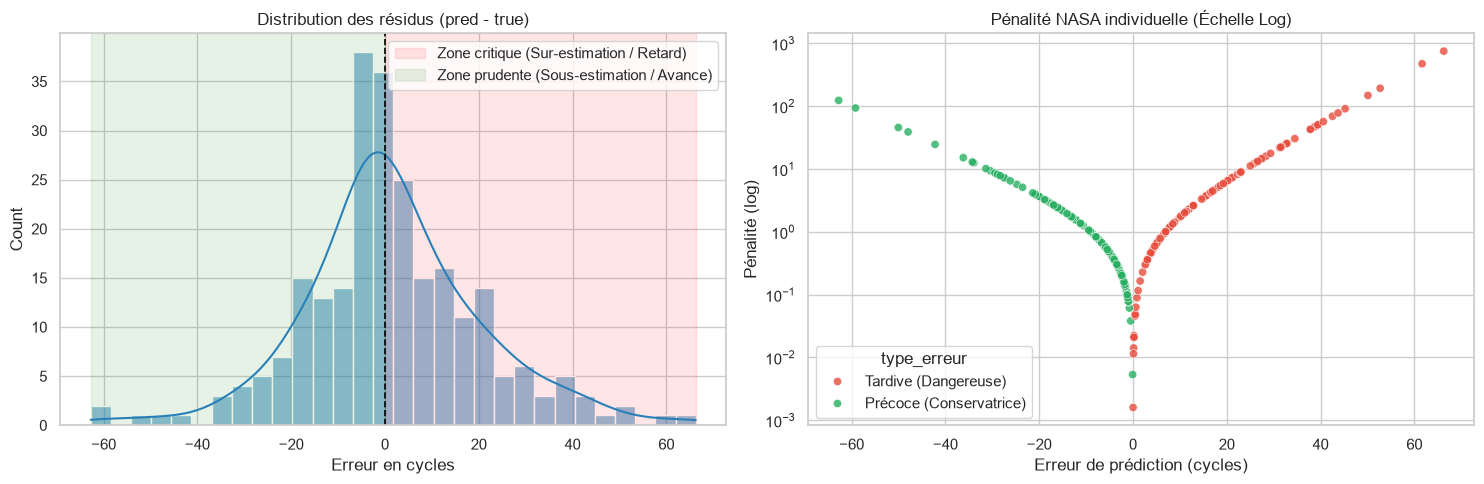

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histogramme des résidus (pred - true)
sns.histplot(df_errors["error"], kde=True, bins=30, ax=ax1, color="#2980b9")
ax1.axvline(0, color="black", linestyle="--", lw=1.2)
ax1.axvspan(
    0,
    df_errors["error"].max(),
    color="red",
    alpha=0.1,
    label="Zone critique (Sur-estimation / Retard)",
)
ax1.axvspan(
    df_errors["error"].min(),
    0,
    color="green",
    alpha=0.1,
    label="Zone prudente (Sous-estimation / Avance)",
)
ax1.set_title("Distribution des résidus (pred - true)")
ax1.set_xlabel("Erreur en cycles")
ax1.legend()

# 2. Scatter plot : Pénalité NASA vs Erreur
sns.scatterplot(
    data=df_errors,
    x="error",
    y="nasa_penalty",
    hue="type_erreur",
    palette={"Tardive (Dangereuse)": "#e74c3c", "Précoce (Conservatrice)": "#27ae60"},
    ax=ax2,
    alpha=0.8,
)
ax2.set_yscale("log")
ax2.set_title("Pénalité NASA individuelle (Échelle Log)")
ax2.set_xlabel("Erreur de prédiction (cycles)")
ax2.set_ylabel("Pénalité (log)")

plt.tight_layout()
plt.savefig(
    "../reports/figures/04_error_distribution.png", dpi=300, bbox_inches="tight"
)
plt.show()